In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/survey lung cancer.csv')

df.info()


FileNotFoundError: [Errno 2] No such file or directory: '/survey lung cancer.csv'

In [ ]:
df.head(50)


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO
5,F,75,1,2,1,1,2,2,2,2,1,2,2,1,1,YES
6,M,52,2,1,1,1,1,2,1,2,2,2,2,1,2,YES
7,F,51,2,2,2,2,1,2,2,1,1,1,2,2,1,YES
8,F,68,2,1,2,1,1,2,1,1,1,1,1,1,1,NO
9,M,53,2,2,2,2,2,1,2,1,2,1,1,2,2,YES


In [ ]:
df.shape

(309, 16)

In [ ]:
print(df['AGE'].describe())


count    309.000000
mean      62.673139
std        8.210301
min       21.000000
25%       57.000000
50%       62.000000
75%       69.000000
max       87.000000
Name: AGE, dtype: float64


In [ ]:
df.columns

Index(['AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE',
       'CHRONIC DISEASE', 'FATIGUE ', 'ALLERGY ', 'WHEEZING',
       'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH',
       'SWALLOWING DIFFICULTY', 'CHEST PAIN', 'LUNG_CANCER', 'GENDER_F',
       'GENDER_M'],
      dtype='object')

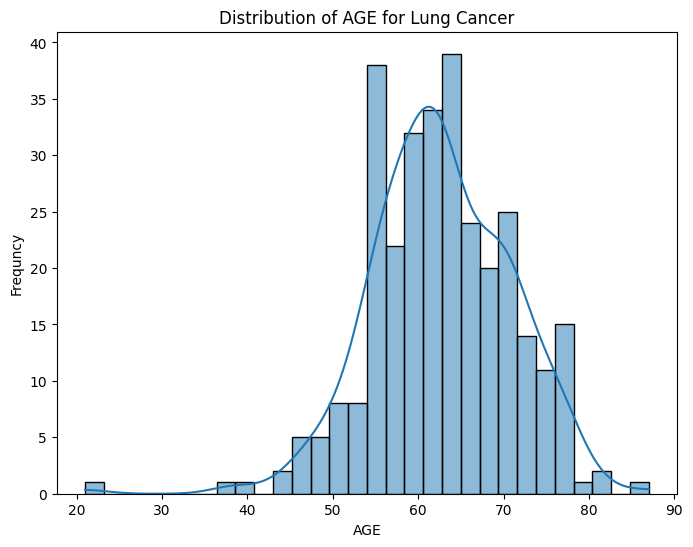

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(df['AGE'],bins=30,kde=True)
plt.title('Distribution of AGE for Lung Cancer')
plt.xlabel('AGE')
plt.ylabel('Frequncy')
plt.show()



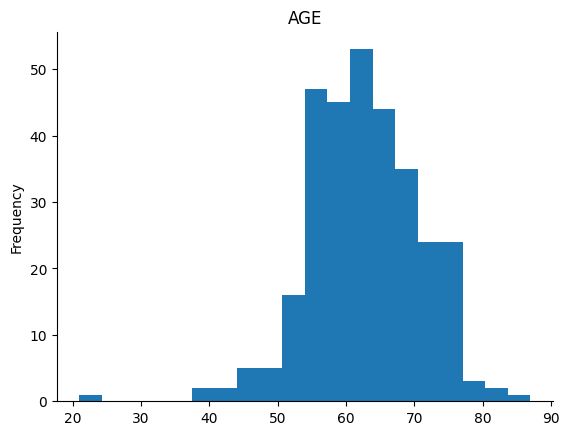

In [ ]:


from matplotlib import pyplot as plt
df['AGE'].plot(kind='hist', bins=20, title='AGE')
plt.gca().spines[['top', 'right',]].set_visible(False)

<ipython-input-39-712b2dabfbde>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='GENDER', data=df, palette='pastel')


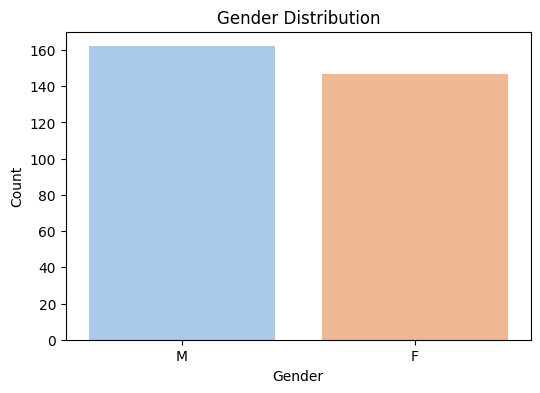

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='GENDER', data=df, palette='pastel')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

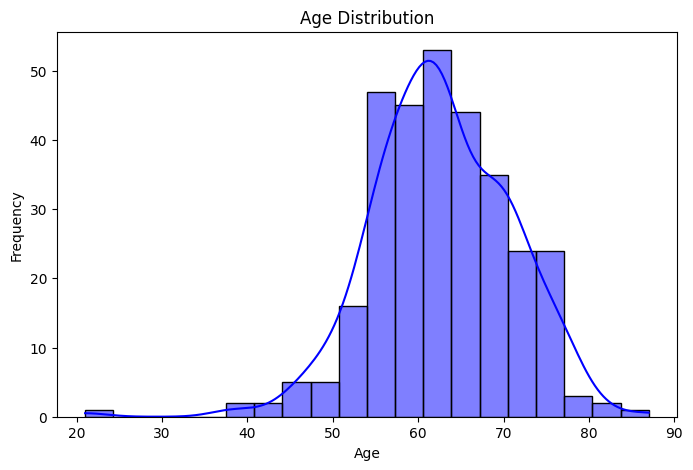

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['AGE'], bins=20, kde=True, color='blue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

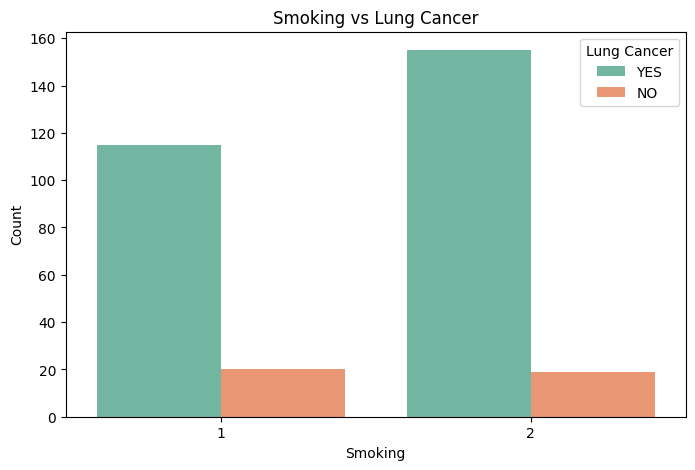

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='SMOKING', hue='LUNG_CANCER', data=df, palette='Set2')
plt.title('Smoking vs Lung Cancer')
plt.xlabel('Smoking')
plt.ylabel('Count')
plt.legend(title='Lung Cancer', loc='upper right')
plt.show()

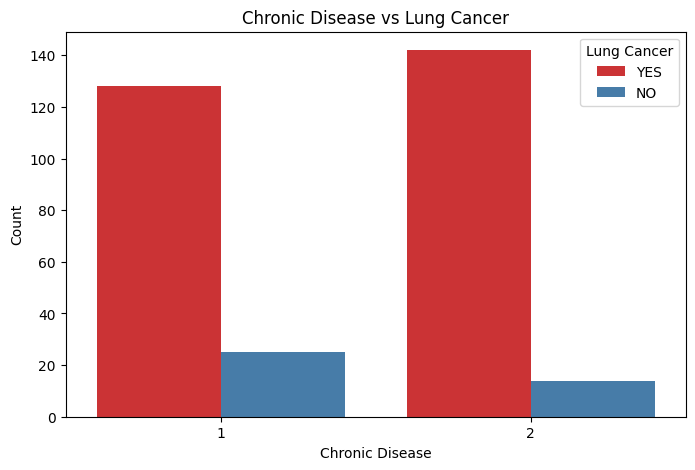

In [ ]:
# Chronic Disease vs Lung Cancer
plt.figure(figsize=(8, 5))
sns.countplot(x='CHRONIC DISEASE', hue='LUNG_CANCER', data=df, palette='Set1')
plt.title('Chronic Disease vs Lung Cancer')
plt.xlabel('Chronic Disease')
plt.ylabel('Count')
plt.legend(title='Lung Cancer', loc='upper right')
plt.show()


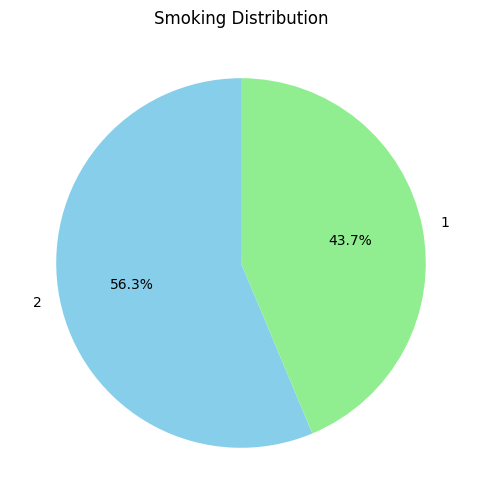

In [ ]:
# Pie Chart for Smoking
smoking_counts = df['SMOKING'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(smoking_counts, labels=smoking_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightgreen'])
plt.title('Smoking Distribution')
plt.show()


<ipython-input-13-5ed424676c1a>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='LUNG_CANCER', y='AGE', data=df, palette='coolwarm')


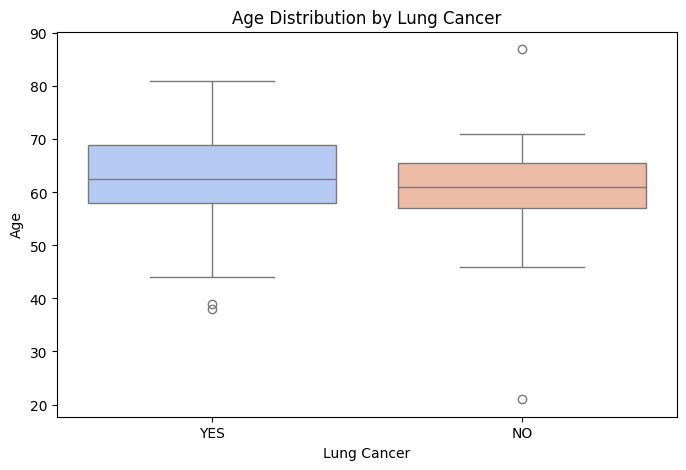

In [ ]:
# Age vs Lung Cancer
plt.figure(figsize=(8, 5))
sns.boxplot(x='LUNG_CANCER', y='AGE', data=df, palette='coolwarm')
plt.title('Age Distribution by Lung Cancer')
plt.xlabel('Lung Cancer')
plt.ylabel('Age')
plt.show()


<ipython-input-14-e8f89ee7a76a>:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='SMOKING', y='COUGHING', hue='LUNG_CANCER', data=df, ci=None, palette='viridis')


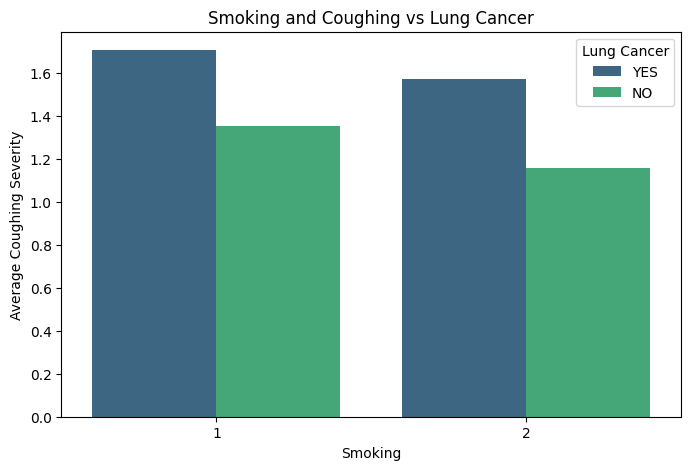

In [ ]:
# Smoking and Coughing vs Lung Cancer
plt.figure(figsize=(8, 5))
sns.barplot(x='SMOKING', y='COUGHING', hue='LUNG_CANCER', data=df, ci=None, palette='viridis')
plt.title('Smoking and Coughing vs Lung Cancer')
plt.xlabel('Smoking')
plt.ylabel('Average Coughing Severity')
plt.legend(title='Lung Cancer', loc='upper right')
plt.show()


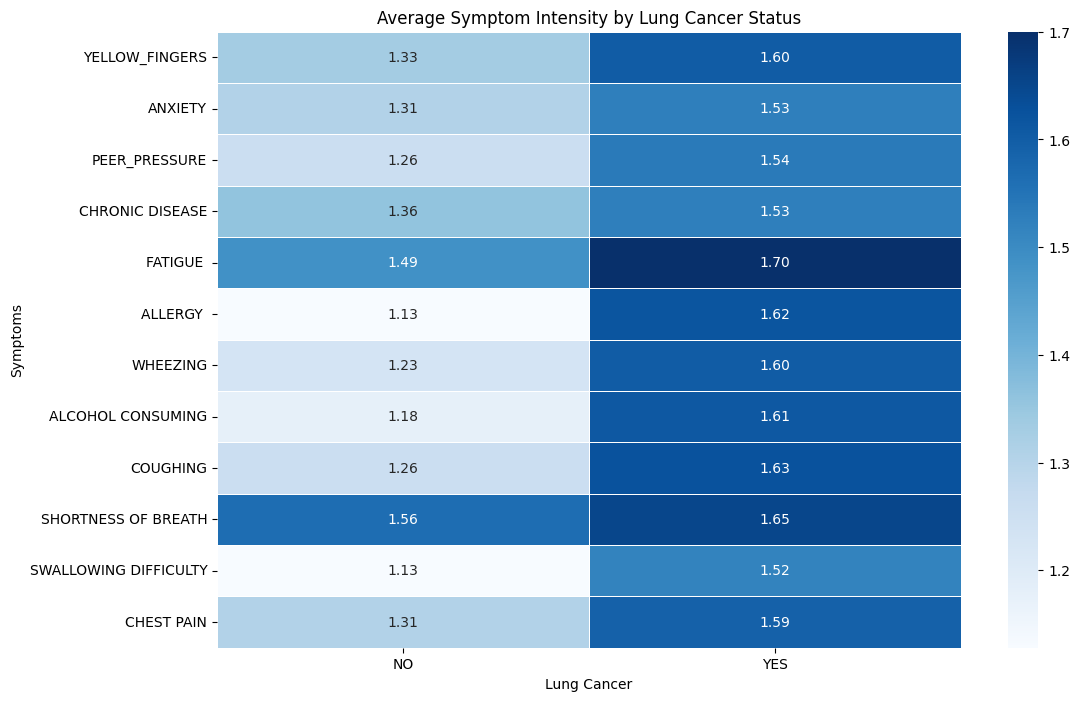

In [ ]:
# Heatmap of Symptoms by Lung Cancer Status
symptoms = ['YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE', 'CHRONIC DISEASE',
            'FATIGUE ', 'ALLERGY ', 'WHEEZING', 'ALCOHOL CONSUMING',
            'COUGHING', 'SHORTNESS OF BREATH', 'SWALLOWING DIFFICULTY', 'CHEST PAIN']

df_symptoms = df[symptoms + ['LUNG_CANCER']].groupby('LUNG_CANCER').mean()

plt.figure(figsize=(12, 8))
sns.heatmap(df_symptoms.T, annot=True, cmap='Blues', fmt=".2f", linewidths=0.5)
plt.title('Average Symptom Intensity by Lung Cancer Status')
plt.xlabel('Lung Cancer')
plt.ylabel('Symptoms')
plt.show()


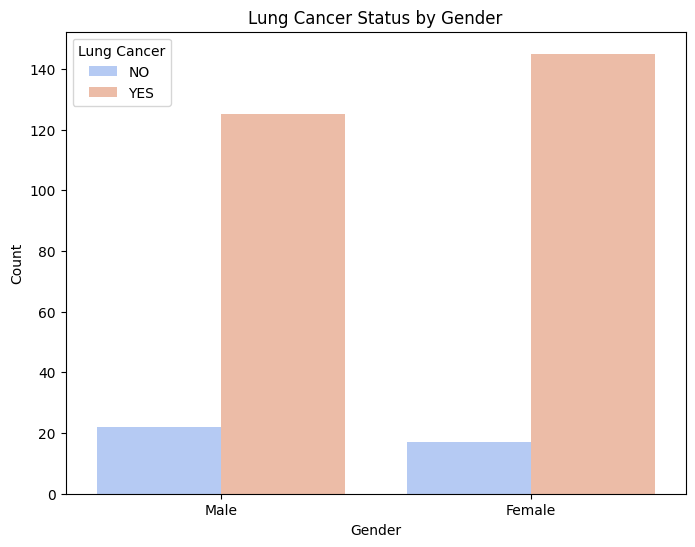

In [ ]:
gender_cancer_counts = df.groupby(['GENDER', 'LUNG_CANCER']).size().reset_index(name='COUNT')

plt.figure(figsize=(8, 6))
sns.barplot(x='GENDER', y='COUNT', hue='LUNG_CANCER', data=gender_cancer_counts, palette='coolwarm')
plt.title('Lung Cancer Status by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Lung Cancer')
plt.xticks(ticks=[0, 1], labels=['Male', 'Female'])
plt.show()

In [ ]:
numeric_columns = [ 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY',
       'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE ', 'ALLERGY ', 'WHEEZING',
       'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH',
       'SWALLOWING DIFFICULTY', 'CHEST PAIN']

categorical_columns = ['GENDER']
df = pd.get_dummies(df, columns=categorical_columns)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
original = df[numeric_columns]
standardizedArray = preprocessing.scale(original)

standardized = pd.DataFrame(standardizedArray, columns=numeric_columns)

In [ ]:
normalizedArray = preprocessing.MinMaxScaler().fit_transform(df[numeric_columns])
normalized = pd.DataFrame(normalizedArray, columns=numeric_columns)
normalized

,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
0,0.727273,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
1,0.803030,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0
2,0.575758,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0
3,0.636364,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
4,0.636364,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,0.530303,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0
305,0.742424,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0
306,0.560606,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0
307,0.696970,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0


In [ ]:
X = df.drop(columns=['LUNG_CANCER'])
y = df['LUNG_CANCER']

In [ ]:
X.shape


(309, 16)

In [ ]:
y.shape

(309,)

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder
# Import the metrics module
from sklearn import metrics # Add this line to import the metrics module
import pandas as pd
import matplotlib.pyplot as plt


X = df.drop(columns=['LUNG_CANCER'])
Y = df['LUNG_CANCER']


X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)


X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')


imputer = SimpleImputer(strategy="mean")
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)


# Convert 'YES' and 'NO' to numerical values using LabelEncoder
le = LabelEncoder()
Y_train = le.fit_transform(Y_train) # Fit and transform on the training data
Y_test = le.transform(Y_test) # Transform the test data using the same encoder



model = XGBRegressor()
model.fit(X_train, Y_train)

print("Model training complete.")




training_data_prediction = model.predict(X_train)



score_1 = metrics.r2_score(Y_train, training_data_prediction)


score_2 = metrics.mean_absolute_error(Y_train, training_data_prediction)

print('R Sqaured Error:', score_1)
print('Mean Absolute Error:', score_2)

Model training complete.
R Sqaured Error: 0.9809269309043884
Mean Absolute Error: 0.005742517473689386


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, Y_train)


y_pred_dtree = dtree.predict(X_test)
print("Decision Tree Classification Report:")
print(classification_report(Y_test, y_pred_dtree))


Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.44      0.53         9
           1       0.91      0.96      0.94        53

    accuracy                           0.89        62
   macro avg       0.79      0.70      0.73        62
weighted avg       0.88      0.89      0.88        62



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay,r2_score, mean_absolute_error

In [ ]:
X = df.drop(columns=['LUNG_CANCER'])
y = df['LUNG_CANCER']

In [ ]:
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
xscale = scale.fit_transform(X)

In [ ]:
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=42)

In [ ]:
X_resampled, y_resampled = ros.fit_resample(xscale, y)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

In [ ]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    conf_matrix = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)


    print(f'{model_name} Accuracy: {accuracy:.2f}')
    print(f'{model_name} Classification Report:\n{class_report}')

    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['No Cancer', 'Has Cancer'])
    disp.plot(cmap='Purples')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

    return accuracy





In [ ]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
lin_reg = LinearRegression()

# Fit the model on the training data
lin_reg.fit(X_train, y_train)

# Evaluate the model using the provided evaluation function
lin_reg_accuracy = evaluate_model(lin_reg, X_test, y_test, 'Linear Regression')

# Output the accuracy or evaluation metric
lin_reg_accuracy


ValueError: could not convert string to float: 'YES'

In [ ]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

LogisticRegression()

Logistic Regression Accuracy: 0.92
Logistic Regression Classification Report:
              precision    recall  f1-score   support

          NO       0.88      0.96      0.92        51
         YES       0.96      0.88      0.92        57

    accuracy                           0.92       108
   macro avg       0.92      0.92      0.92       108
weighted avg       0.92      0.92      0.92       108



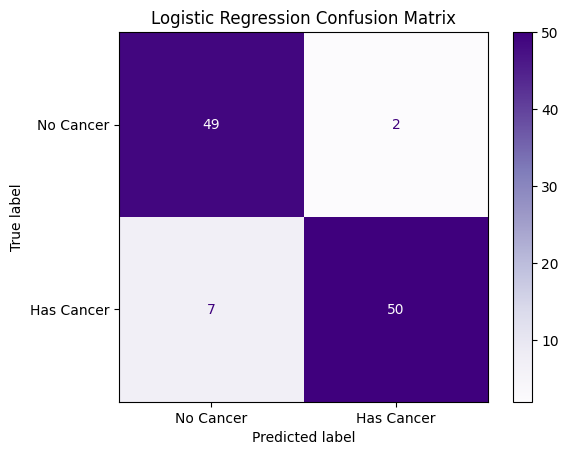

0.9166666666666666

In [ ]:
log_reg_accuracy =evaluate_model(log_reg, X_test, y_test, 'Logistic Regression')
log_reg_accuracy


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score


label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)


log_reg = LogisticRegression()
log_reg.fit(X_train, y_train_encoded)

def evaluate_model_r2(model, X_test, y_test_encoded, model_name):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test_encoded, y_pred)
    print(f"{model_name} R^2: {r2:.4f}")
    return r2

log_reg_r2 = evaluate_model_r2(log_reg, X_test, y_test_encoded, 'Logistic Regression')
log_reg_r2


Logistic Regression R^2: 0.6656


0.6656346749226005

In [ ]:
svc = SVC()
svc.fit(X_train, y_train)

SVC()

Support Vector Classifier Accuracy: 0.95
Support Vector Classifier Classification Report:
              precision    recall  f1-score   support

          NO       0.91      1.00      0.95        51
         YES       1.00      0.91      0.95        57

    accuracy                           0.95       108
   macro avg       0.96      0.96      0.95       108
weighted avg       0.96      0.95      0.95       108



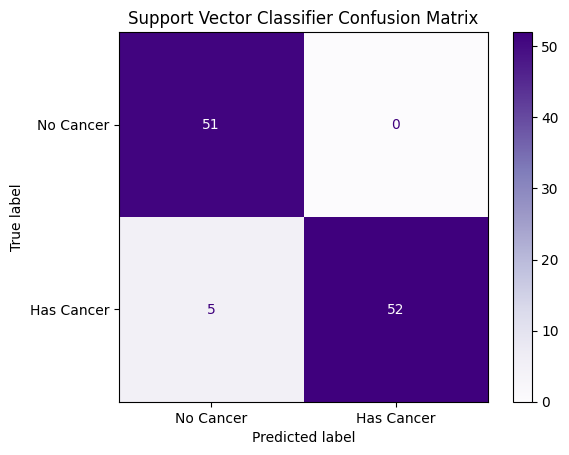

0.9537037037037037

In [ ]:
svc_accuracy =evaluate_model(svc, X_test, y_test, 'Support Vector Classifier')
svc_accuracy

In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

svc = SVC()
svc.fit(X_train, y_train_encoded)

def evaluate_model_r2(model, X_test, y_test_encoded, model_name):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test_encoded, y_pred)
    print(f"{model_name} R^2: {r2:.4f}")
    return r2

svc_r2 = evaluate_model_r2(svc, X_test, y_test_encoded, 'Support Vector Classifier')
svc_r2


Support Vector Classifier R^2: 0.8142


0.8142414860681114

In [ ]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

Random Forest Classifier Accuracy: 0.99
Random Forest Classifier Classification Report:
              precision    recall  f1-score   support

          NO       0.98      1.00      0.99        51
         YES       1.00      0.98      0.99        57

    accuracy                           0.99       108
   macro avg       0.99      0.99      0.99       108
weighted avg       0.99      0.99      0.99       108



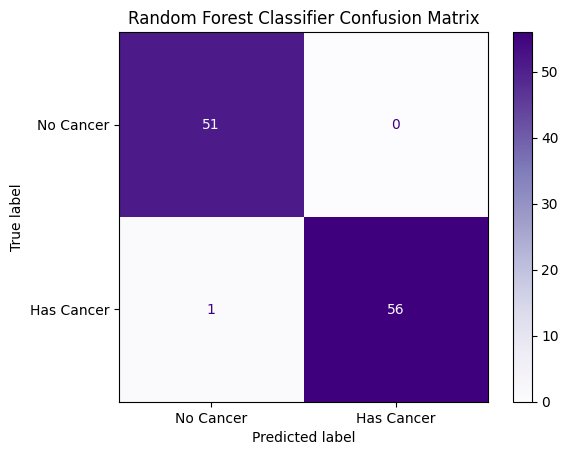

0.9907407407407407

In [ ]:
rf_accuracy= evaluate_model(rf, X_test, y_test, 'Random Forest Classifier')
rf_accuracy

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

rf.fit(X_train, y_train_encoded)

def evaluate_model_r2(model, X_test, y_test_encoded, model_name):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test_encoded, y_pred)
    print(f"{model_name} R^2: {r2:.4f}")
    return r2

rf_r2 = evaluate_model_r2(rf, X_test, y_test_encoded, 'Random Forest Classifier')
rf_r2


Random Forest Classifier R^2: 0.9628


0.9628482972136223

In [ ]:
gbc = GradientBoostingClassifier()
gbc.fit(X_train, y_train)

GradientBoostingClassifier()

Gradient Boosting Classifier Accuracy: 0.96
Gradient Boosting Classifier Classification Report:
              precision    recall  f1-score   support

          NO       0.93      1.00      0.96        51
         YES       1.00      0.93      0.96        57

    accuracy                           0.96       108
   macro avg       0.96      0.96      0.96       108
weighted avg       0.97      0.96      0.96       108



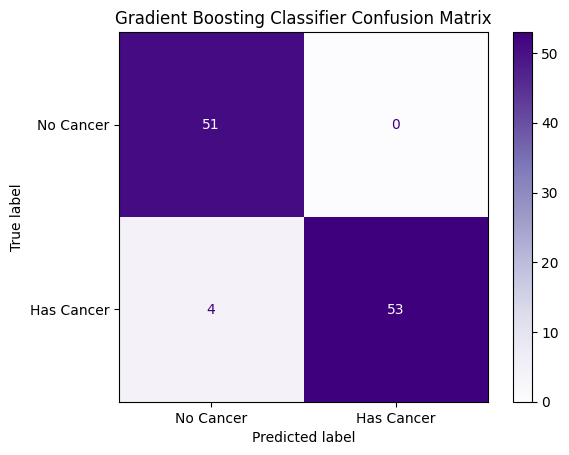

0.9629629629629629

In [ ]:
gbc_accuracy = evaluate_model(gbc, X_test, y_test, 'Gradient Boosting Classifier')
gbc_accuracy

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score

# Encode the target labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

gbc = GradientBoostingClassifier()
gbc.fit(X_train, y_train_encoded)

def evaluate_model_r2(model, X_test, y_test_encoded, model_name):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test_encoded, y_pred)
    print(f"{model_name} R^2: {r2:.4f}")
    return r2

gbc_r2 = evaluate_model_r2(gbc, X_test, y_test_encoded, 'Gradient Boosting Classifier')
gbc_r2


Gradient Boosting Classifier R^2: 0.8514


0.8513931888544891

              precision    recall  f1-score   support

          NO       0.96      1.00      0.98        51
         YES       1.00      0.96      0.98        57

    accuracy                           0.98       108
   macro avg       0.98      0.98      0.98       108
weighted avg       0.98      0.98      0.98       108



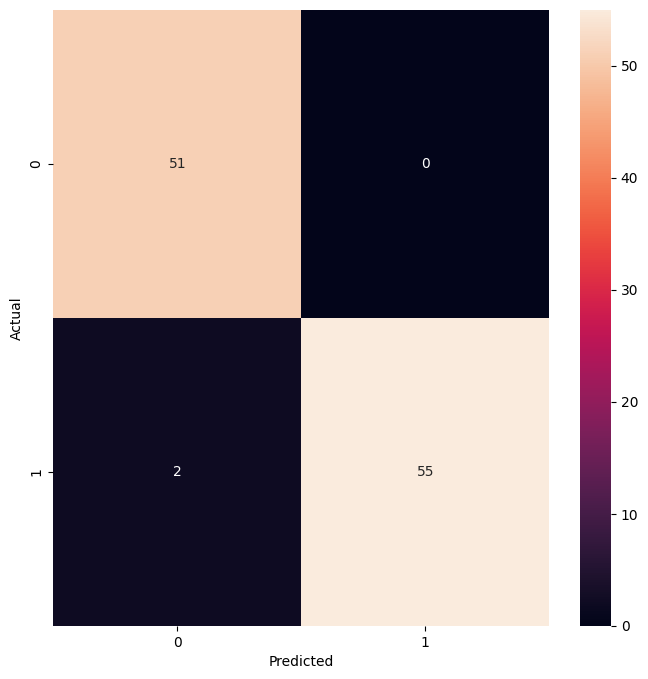

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
knn=KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train,y_train)
from sklearn.metrics import confusion_matrix
confusion_knn=confusion_matrix(y_test,knn.predict(X_test))
plt.figure(figsize=(8,8))
sns.heatmap(confusion_knn,annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
from sklearn.metrics import classification_report
print(classification_report(y_test,knn.predict(X_test)))

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score
from sklearn.neighbors import KNeighborsClassifier

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)


knn = KNeighborsClassifier()
knn.fit(X_train, y_train_encoded)


def evaluate_model_r2(model, X_test, y_test_encoded, model_name):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test_encoded, y_pred)
    print(f"{model_name} R^2: {r2:.4f}")
    return r2


knn_r2 = evaluate_model_r2(knn, X_test, y_test_encoded, 'K-Nearest Neighbors Classifier')
knn_r2


K-Nearest Neighbors Classifier R^2: 0.7771


0.7770897832817337

              precision    recall  f1-score   support

          NO       1.00      1.00      1.00        51
         YES       1.00      1.00      1.00        57

    accuracy                           1.00       108
   macro avg       1.00      1.00      1.00       108
weighted avg       1.00      1.00      1.00       108



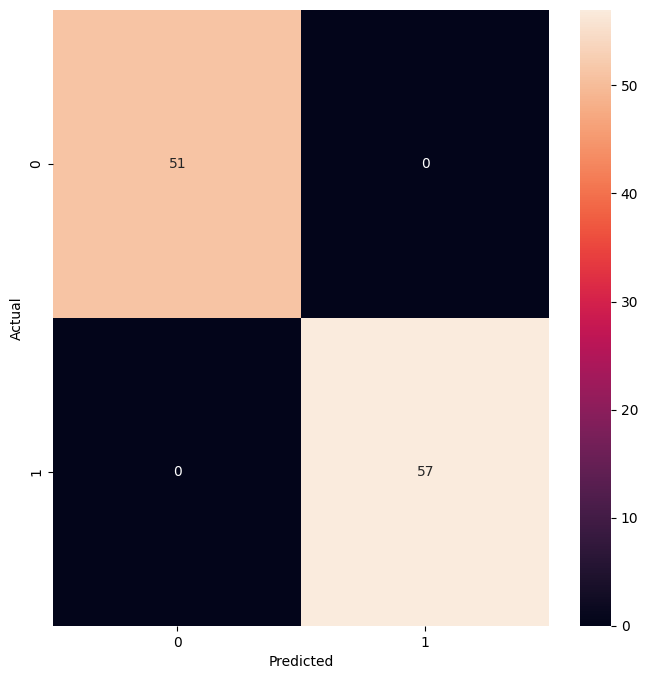

In [ ]:
model = SVC(gamma=10,C=100)
model.fit(X_train,y_train)
y_pred_svc=model.predict(X_test)
confusion_svc=confusion_matrix(y_test,y_pred_svc)
plt.figure(figsize=(8,8))
sns.heatmap(confusion_svc,annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
print(classification_report(y_test,y_pred_svc))

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score
from sklearn.tree import DecisionTreeClassifier


label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)


dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train_encoded)


def evaluate_model_r2(model, X_test, y_test_encoded, model_name):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test_encoded, y_pred)
    print(f"{model_name} R^2: {r2:.4f}")
    return r2


dtc_r2 = evaluate_model_r2(dtc, X_test, y_test_encoded, 'Decision Tree Classifier')
dtc_r2


Decision Tree Classifier R^2: 0.8514


0.8513931888544891